In [3]:
import pandas as pd
import numpy as np
import scipy.io as sio

import os.path
import time
import random
import math

In [4]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

In [5]:
def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

In [6]:
def RevOneHotEncode(arr):
    seq2=""
    for i in arr:
        if (i[0] == 1):
            seq2+='A';
        elif (i[1] == 1):
            seq2+='C';
        elif (i[2] == 1):
            seq2+='G';
        elif (i[3] == 1):
            seq2+='T';
        else:
            seq2+='N';
    return seq2;

In [7]:
def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [133]:
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)
    

In [117]:
def SD_calculation(seq, tb, DNAshape):
    # print(tb.keys())'
    N=10 # calculate SD value for every 10 bps
    shape_values = []

    #Initial the first pentamer
    pentamer = RevOneHotEncode(seq[0:5])
    if pentamer not in tb.keys():
        pentamer = reverse_complement(pentamer)
    for i in range(len(DNAshape)):
        shape_values.append(tb.get(pentamer)[i])

    for i in range(1, len(seq)-5):
        pentamer = RevOneHotEncode(seq[i:i+5])
        if pentamer not in tb.keys():
            pentamer = reverse_complement(pentamer)
        else:
            for j in range(0, len(DNAshape)):
                shape_values[j] = shape_values[j] + tb.get(pentamer)[j]
    return shape_values;

In [9]:
def nucseq_shape_analysis(fname, out, DNAshape, tb):

    # Open and read file
    if os.path.isfile(fname):
        mat_contents = sio.loadmat(fname)
        edata=mat_contents['EnrichedData']
        ddata=mat_contents['DepletedData']
#     print(tb)

    shapes = []
    np_allEnrichSeqArr = np.array(edata)
    np_allDepleteSeqArr = np.array(ddata)
    print(f"3 np_allEnrichSeqArr.shape {np_allEnrichSeqArr.shape}, np_allDepleteSeqArr.shape {np_allDepleteSeqArr.shape}");
    for d in ddata:
        if 'N' not in d:
            shape_values = SD_calculation(d, tb, DNAshape)
            shapes.append(shape_values)

    string = ""
    for line in shapes:
        curr_str = " ".join(str(s) for s in line)
        string = string + curr_str + "\n"
    
    f = open(out, 'w+');
    f.write(string)
    f.write("\n")
    f.close()

In [195]:
def shape_param_analysis(tb):
    
    
#     intra_rot = [3:5]
#     inter_trans = [6:11]
#     inter_rot = [12:17]
#     GrooveWidth = [18:21]
    
#     intra_trans_SD = [22:24]
#     inter_trans_SD = [25:27]
#     intra_rot_SD = [28:30]
#     inter_rot_SD= [31:33]
#     GrooveWidth_SD = [34:37]


    all_shape_vals = []
    for pentamer in tb.keys():
        shape_vals = tb[pentamer]
        all_shape_vals+= [shape_vals]
    all_shape_vals2 = np.array(all_shape_vals).T
    all_norm_shape_vals = []
    
    # Perform per-shape normalization
    from sklearn import preprocessing
    for shape in all_shape_vals2:
        all_norm_shape_vals+= [min_max_norm(shape)]
#     print(np.array(all_norm_shape_vals).shape)
    return all_norm_shape_vals, all_shape_vals2;

In [209]:
intra_trans = list(range(0,3))
intra_rot = list(range(3,6))
inter_trans = list(range(6,12))
inter_rot = list(range(12,18))

GrooveWidth = list(range(18,22))
intra_trans_SD = list(range(22,25))
intra_rot_SD = list(range(25,28))
inter_trans_SD = list(range(28,31))
inter_rot_SD=  list(range(31,34))
GrooveWidth_SD = list(range(34,37))

All_params = [intra_trans, intra_rot,inter_trans,inter_rot,GrooveWidth,intra_trans_SD,inter_trans_SD,intra_rot_SD,inter_rot_SD,GrooveWidth_SD]

print(All_params)   

[[0, 1, 2], [3, 4, 5], [6, 7, 8, 9, 10, 11], [12, 13, 14, 15, 16, 17], [18, 19, 20, 21], [22, 23, 24], [28, 29, 30], [25, 26, 27], [31, 32, 33], [34, 35, 36]]


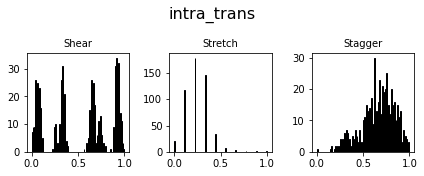

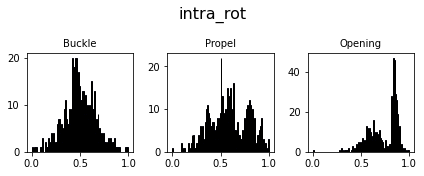

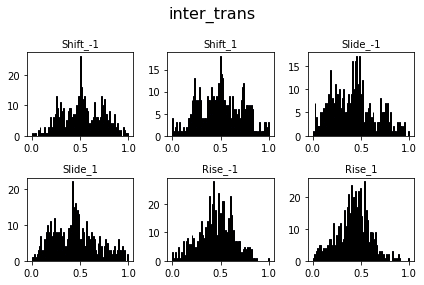

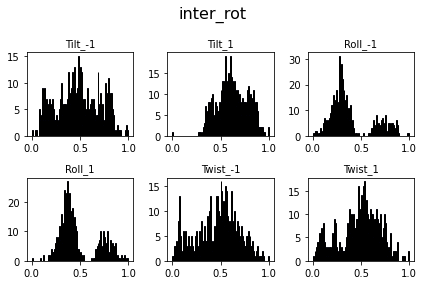

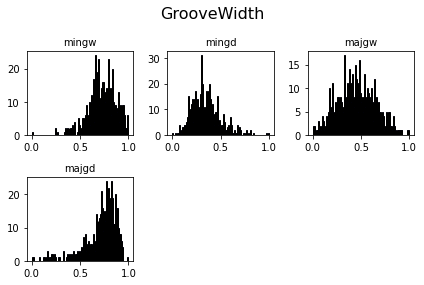

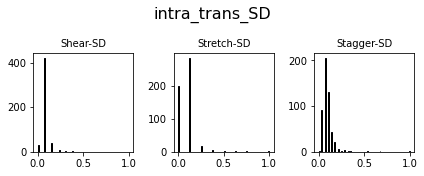

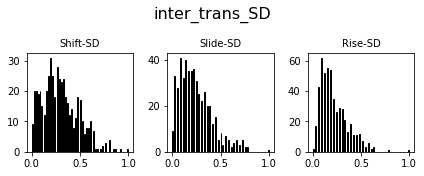

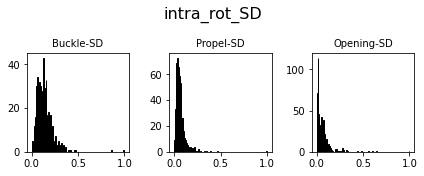

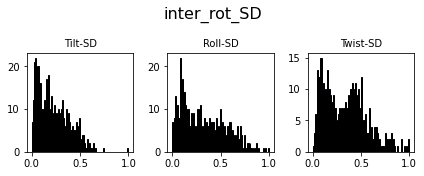

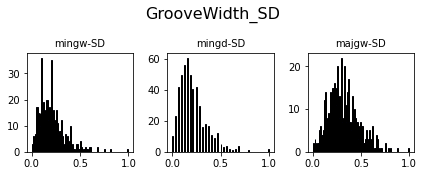

In [208]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);
    
##### 1
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)

# fig, axs = plt.subplots(1, 3, tight_layout=True)

# # N is the count in each bin, bins is the lower-limit of the bin

for i in range(len(All_params)):
    pic_index = All_params[i]
    fig = plt.figure()
    fig.suptitle(All_params_names[i], fontsize=16)

    for j in range(len(pic_index)):

        # Set up the plot
        row = len(All_params[i])/3
        ax = plt.subplot(2, 3, j+1)
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        ax.hist(x, bins = 100,
                 color = 'blue', edgecolor = 'black')
    
        # Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 10)

    plt.tight_layout()
    plt.savefig(All_params_names[i]+".jpg")

##### 2
# fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/train_test_data/nucleosome_occupancy_30.mat'
# E_out = "Edata_SD_values.txt"
# D_out = "Ddata_SD_values.txt"

# nucseq_shape_analysis(fname, D_out, AllDNAshape[3:5], tb)

In [270]:
def pltcolor(lst):
    cols=[]
    for l in lst:
        if l=='A':
            cols.append([0.2, 0.1, 0.1])
        elif l=='AA':
            cols.append([0.4, 0.1, 0.1])
        elif l=='AAA':
            cols.append([0.6, 0.1, 0.1])
        elif l=='AAAA':
            cols.append([0.8, 0.1, 0.1])
        elif l=='AAAAA':
            cols.append([1, 0.1, 0.1])
        elif l=='C':
            cols.append([0.1,0.2, 0.1])
        elif l=='CC':
            cols.append([0.1,0.4, 0.1])
        elif l=='CCC':
            cols.append([0.1,0.6, 0.1])
        elif l=='CCCC':
            cols.append([0.1,0.8, 0.1])
        elif l=='CCCCC':
            cols.append([0.1,1, 0.1])
        elif l=='G':
            cols.append([0.1,0.2, 0.1])
        elif l=='GG':
            cols.append([0.1,0.4, 0.1])
        elif l=='GGG':
            cols.append([0.1,0.6, 0.1])
        elif l=='GGGG':
            cols.append([0.1,0.8, 0.1])
        elif l=='GGGGG':
            cols.append([0.1, 1, 0.1])
        elif l=='T':
            cols.append(0.2)
        elif l=='TT':
            cols.append(0.4)
        elif l=='TTT':
            cols.append(0.6)
        elif l=='TTTT':
            cols.append(0.8)
        elif l=='TTTTT':
            cols.append(1)
    return cols

In [348]:
def pltcolor(lst):
    cols=[]
    for l in lst:
        if l=='A':
            cols.append(5)
        elif l=='AA':
            cols.append(4)
        elif l=='AAA':
            cols.append(3)
        elif l=='AAAA':
            cols.append(2)
        elif l=='AAAAA':
            cols.append(1)
        elif l=='C':
            cols.append(5)
        elif l=='CC':
            cols.append(4)
        elif l=='CCC':
            cols.append(3)
        elif l=='CCCC':
            cols.append(2)
        elif l=='CCCCC':
            cols.append(1)
        elif l=='G':
             cols.append(5)
        elif l=='GG':
            cols.append(4)
        elif l=='GGG':
            cols.append(3)
        elif l=='GGGG':
            cols.append(2)
        elif l=='GGGGG':
            cols.append(1)
        elif l=='T':
            cols.append(5)
        elif l=='TT':
            cols.append(4)
        elif l=='TTT':
            cols.append(3)
        elif l=='TTTT':
            cols.append(2)
        elif l=='TTTTT':
            cols.append(1)
    return cols


In [314]:
color_group = []
debug = 0
# print(tb.keys())

for pentamer in tb.keys():
#     if debug < 10:
    curr_seq = ''
    longest = ''
    for letter in pentamer:
        if len(curr_seq) == 0: 
            curr_seq = letter
        else:
            if curr_seq[-1] != letter:
                if len(curr_seq) > len(longest):
                    longest = curr_seq
                curr_seq = letter

            else:
                curr_seq += letter
                if len(curr_seq) == 5:
                    longest = curr_seq
    color_group += [longest]
    debug += 1

all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)

# cols=pltcolor(color_group)
# plt.scatter(tb.keys(), all_norm_shape_vals[0], s=10, c=cols, cmap='Spectral')
# plt.colorbar()


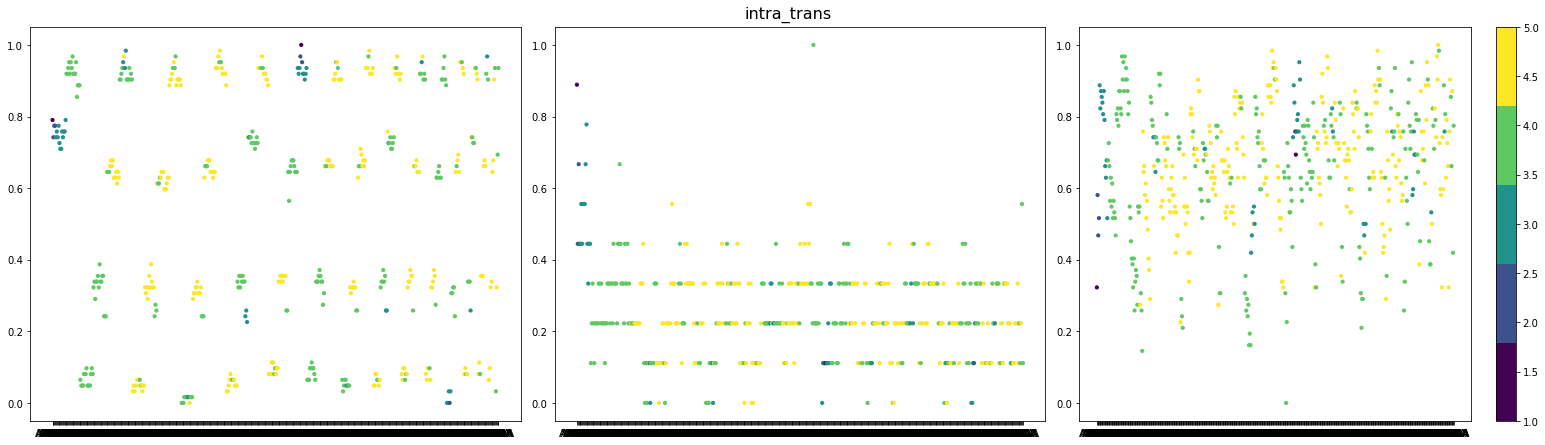

<Figure size 432x288 with 0 Axes>

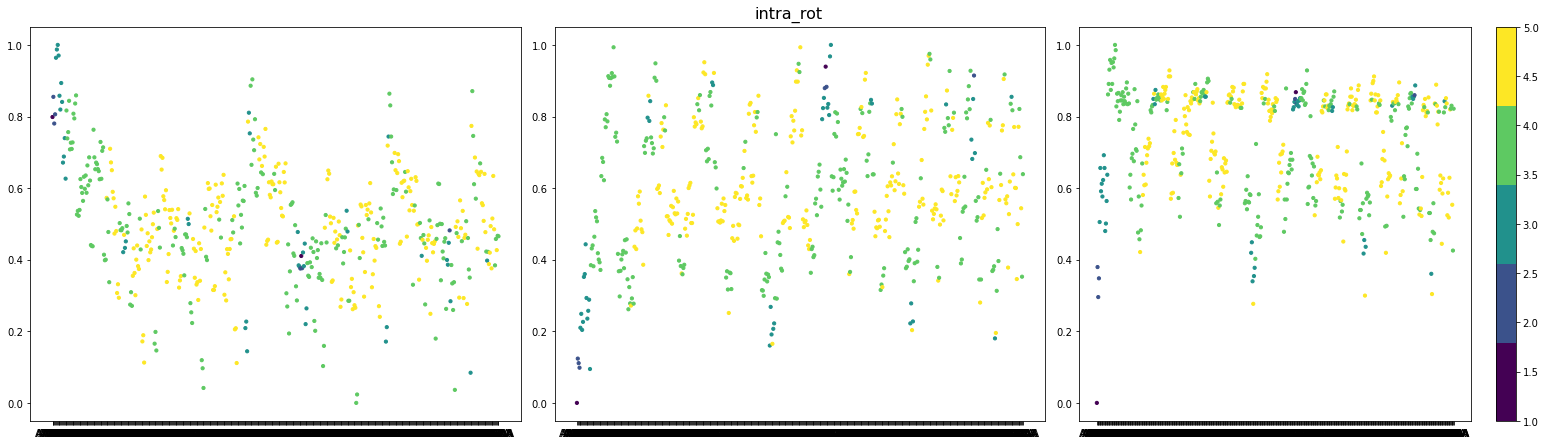

<Figure size 432x288 with 0 Axes>

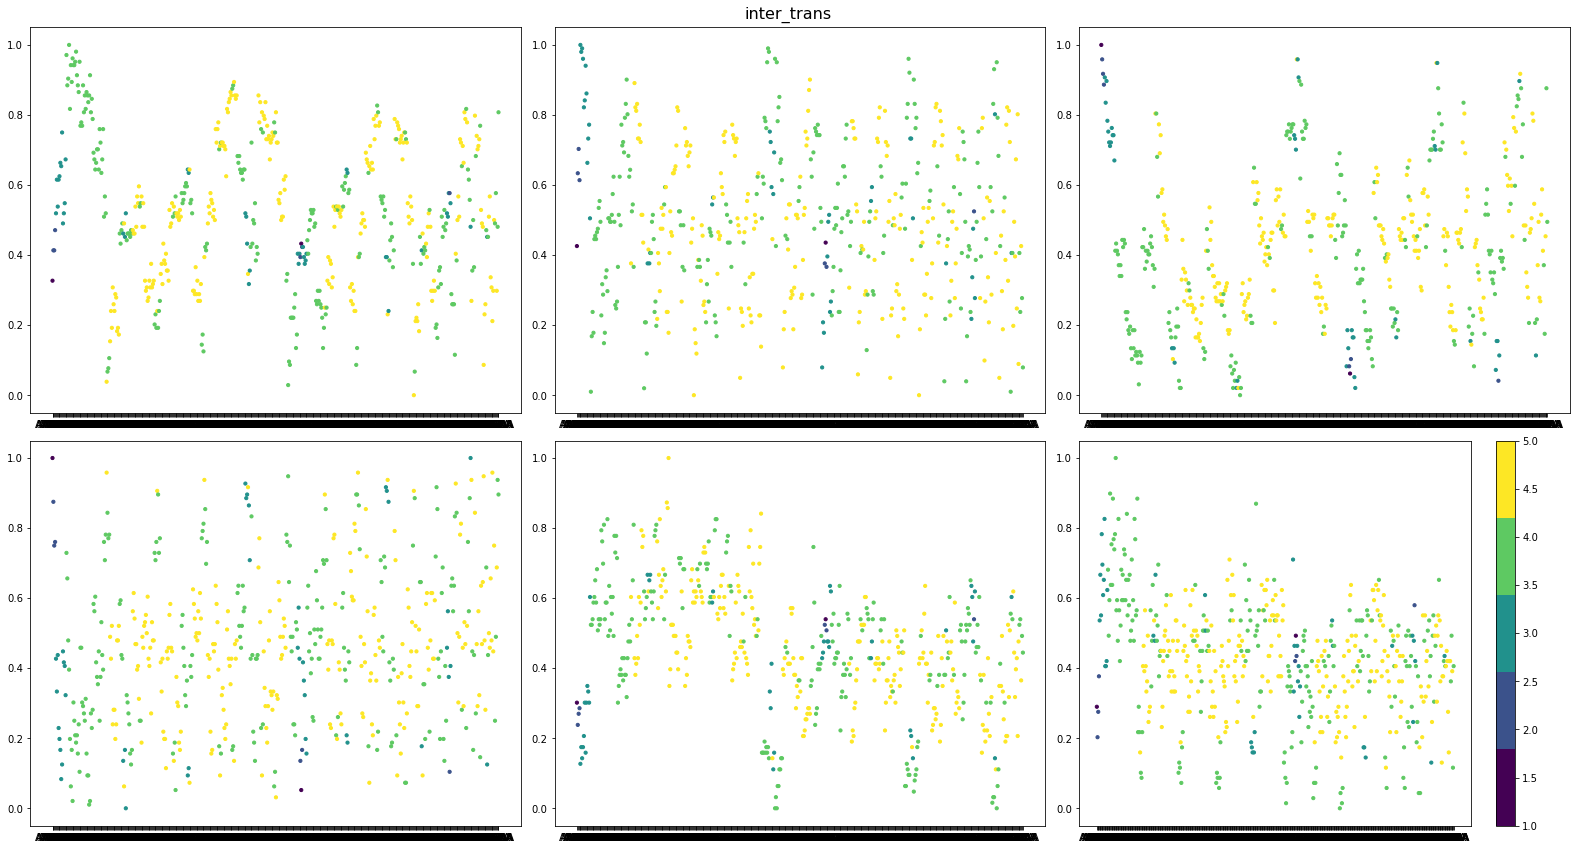

<Figure size 432x288 with 0 Axes>

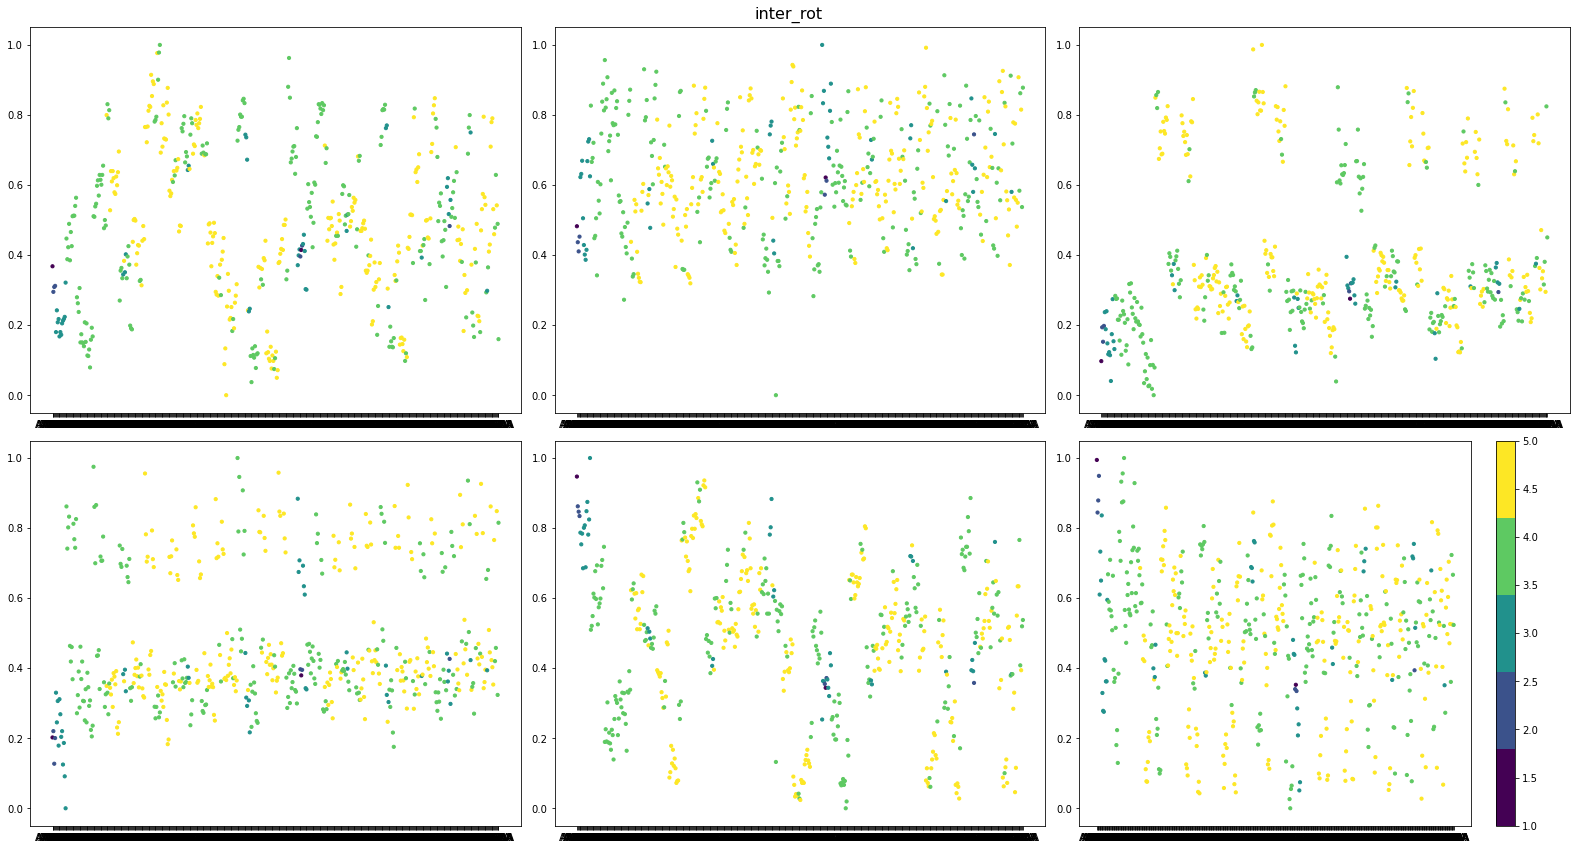

<Figure size 432x288 with 0 Axes>

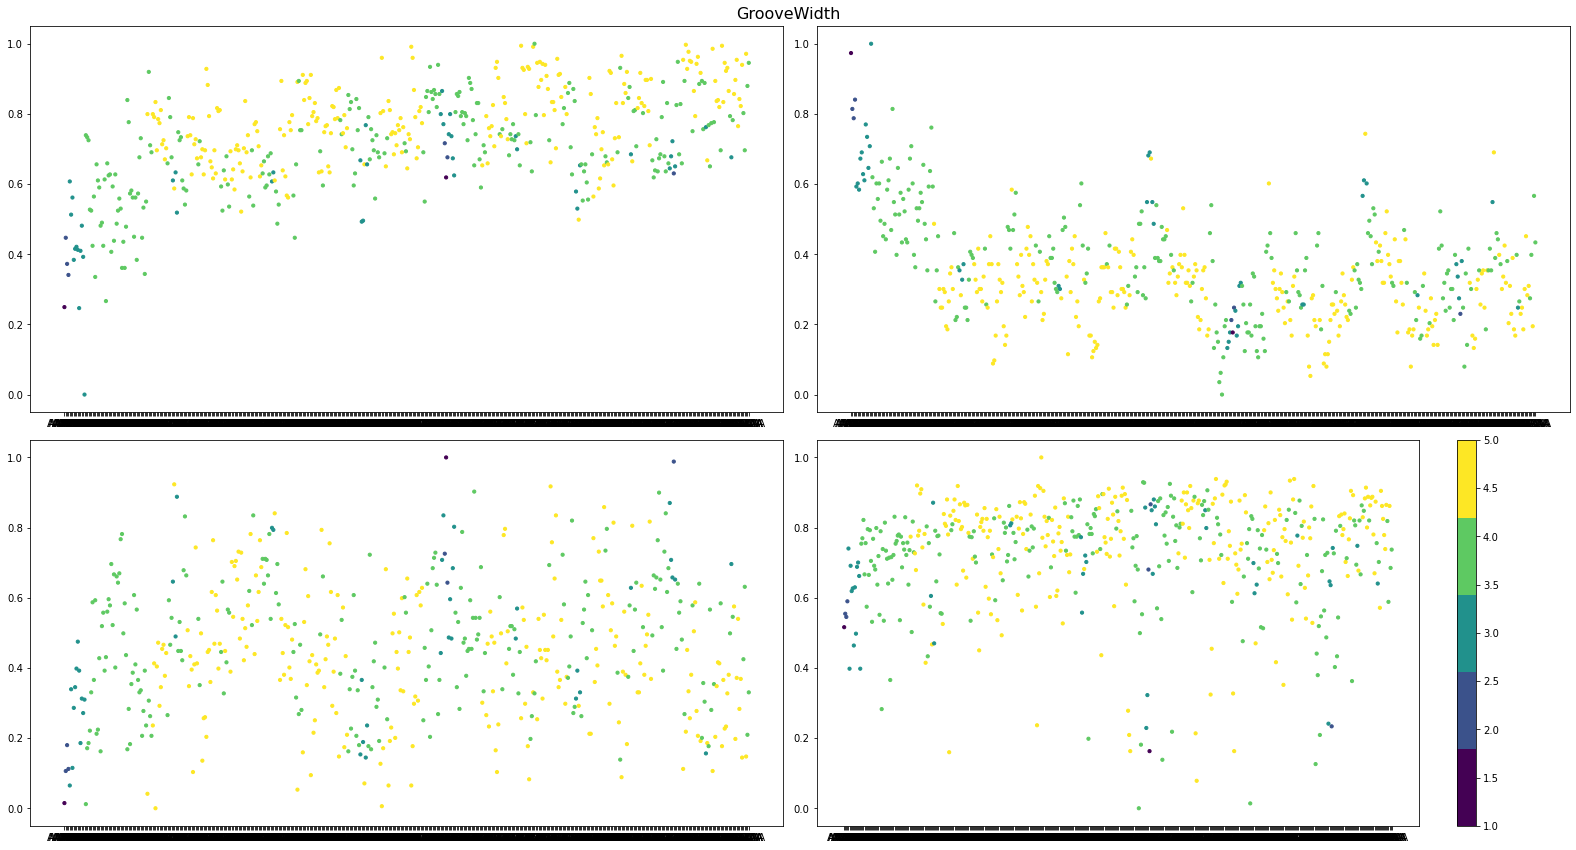

<Figure size 432x288 with 0 Axes>

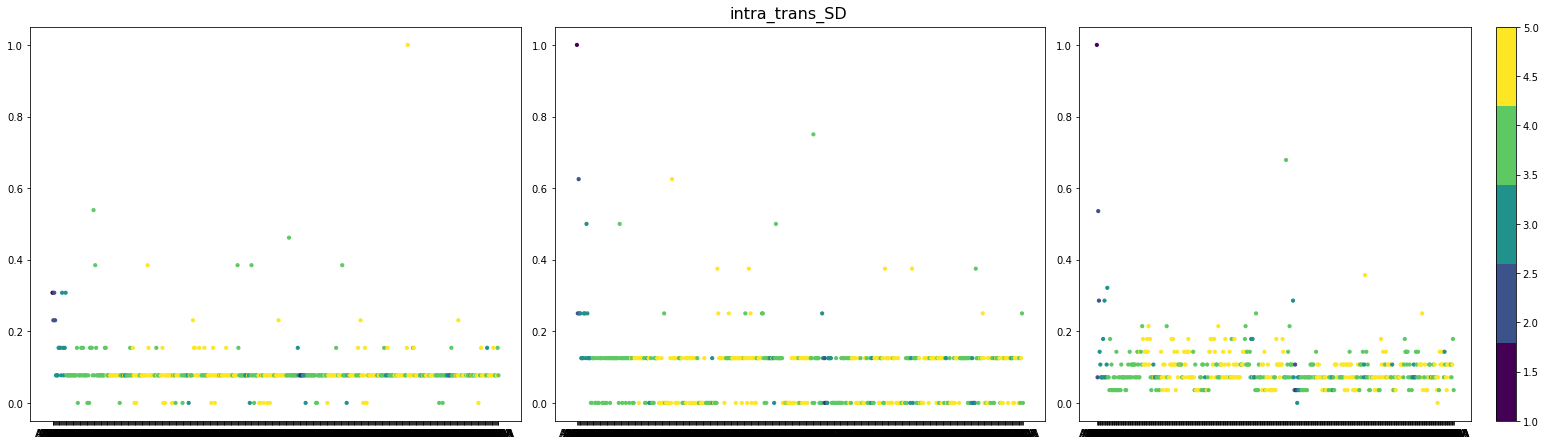

<Figure size 432x288 with 0 Axes>

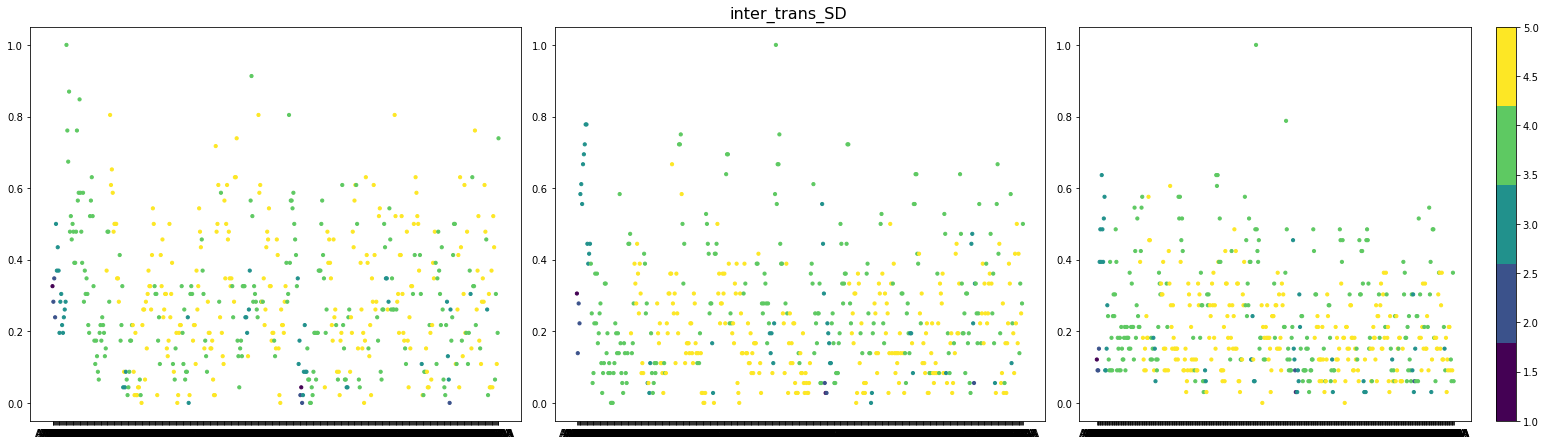

<Figure size 432x288 with 0 Axes>

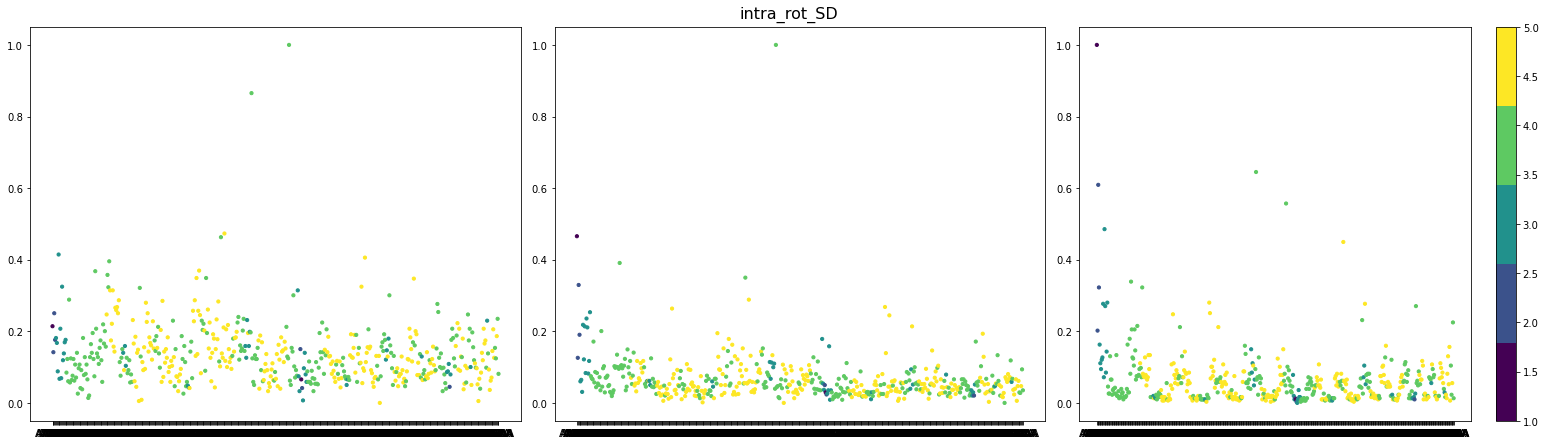

<Figure size 432x288 with 0 Axes>

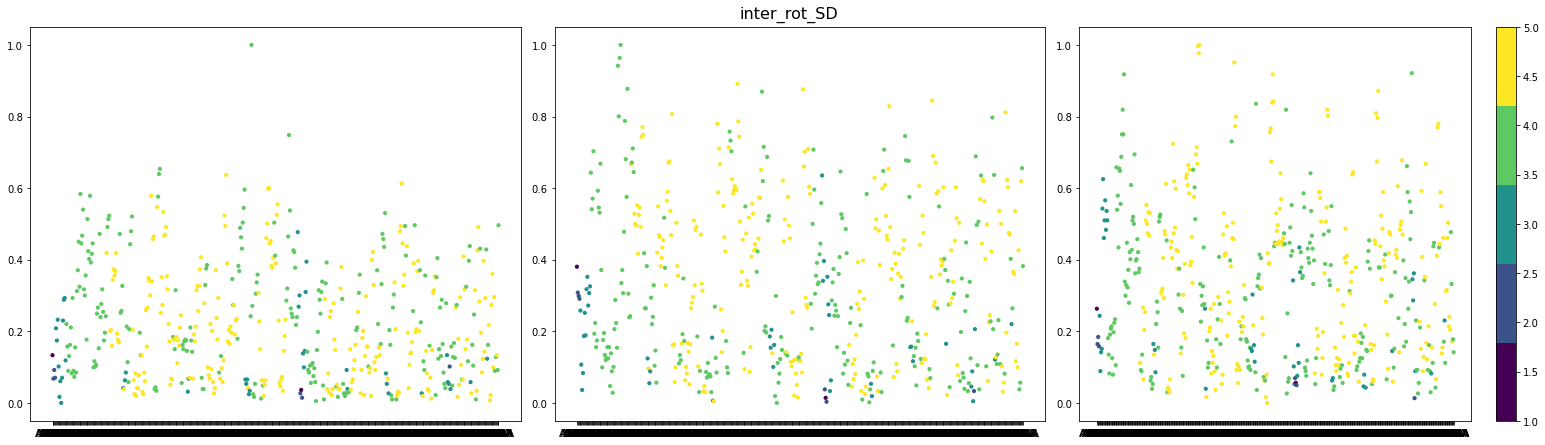

<Figure size 432x288 with 0 Axes>

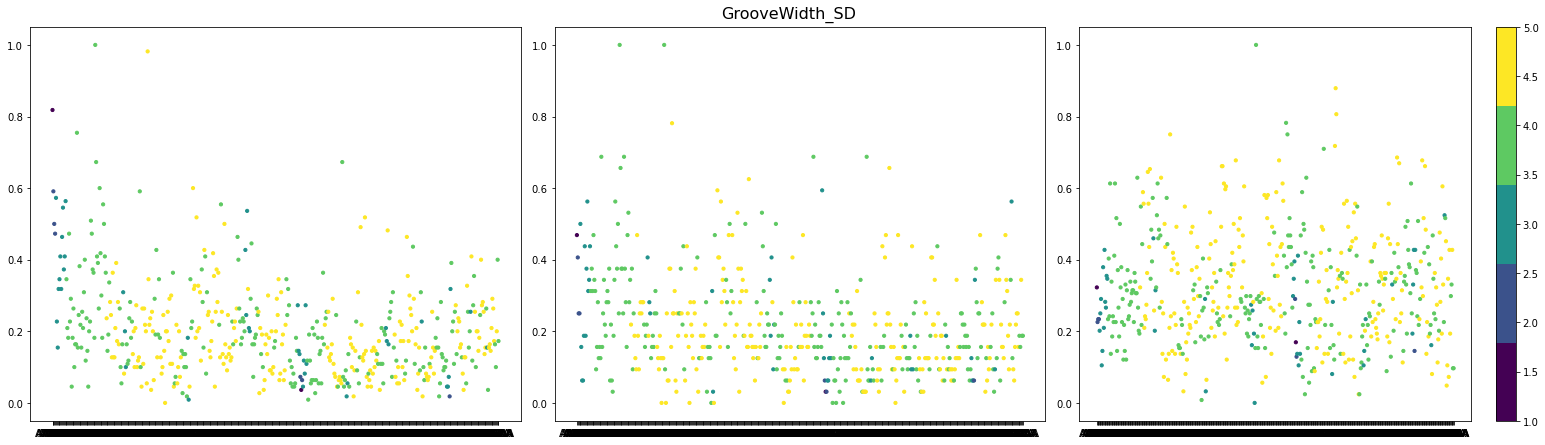

<Figure size 432x288 with 0 Axes>

In [366]:
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import  matplotlib.cm as cm

all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)

# fig, axs = plt.subplots(1, 3, tight_layout=True)

# # N is the count in each bin, bins is the lower-limit of the bin

for i in range(len(All_params)):
    pic_index = All_params[i]
    fig = plt.figure(figsize=(22,12))
#     fig = plt.figure()
    fig.suptitle(All_params_names[i], fontsize=16)
    total_plot_num = len(pic_index)

    for j in range(len(pic_index)):

        # Set up the plot
#         axs = plt.subplot(2, 3, j+1)
        r = 0
        c = 0
        if (total_plot_num % 3 == 0):
            axs = plt.subplot(2, 3, j+1)
            r = int(total_plot_num/3);
#             c = 3
        elif (total_plot_num % 2 == 0):
            axs = plt.subplot(2, 2, j+1)
            r = int(total_plot_num/2);
#             c = 2
    
        # Draw the plot
        x = all_norm_shape_vals[pic_index[j]]
        cols=pltcolor(color_group)
        pcm = plt.scatter(tb.keys(), x, s=10, c=cols, cmap=cm.get_cmap('viridis', 5))

#         Title and labels
        ax.set_title('%s' % AllDNAshape[pic_index[j]], size = 15)

        ax.axvline(x='AAAAA', color='red')
        ax.axvline(x='CAAAA', color='yellow')
        ax.axvline(x='GAAAA', color='green')
        ax.axvline(x='TAAAA', color='blue')
#         ax.text(x='AAAAA','A',rotation=90)
#         ax.text(x='CAAAA','C',rotation=90)
#         ax.text(x='GAAAA','G',rotation=90)
    #         ax.text(x='TAAAA','T',rotation=90)

    plt.tight_layout()
    cbar = plt.colorbar()
#     cax = plt.axes([0.85, 0.1, 0.075, 0.8])
#     cax = plt.axes([1, 0, 0.075, 0.8])
#     plt.colorbar(cax=cax)
#     cbar.set_label('# of consecutive nt', rotation=270)
#     for row in range(r):
#         plt.colorbar(pcm, location='right')
#     plt.colorbar(pcm, ax=ax)
#     plt.colorbar(pcm, ax=[axs[2, 1]], location='left')
    plt.show()
    plt.savefig(All_params_names[i]+"_scatter.jpg")

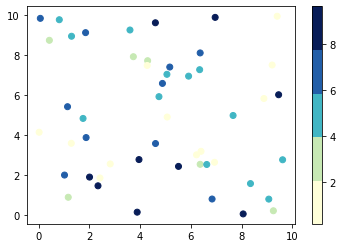

In [340]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import  matplotlib.cm as cm

# cmap = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap("tab20c").colors)
cMap = cm.get_cmap('YlGnBu', 5)

# print(cmap)
plt.scatter(np.random.uniform(0, 10, 50), np.random.uniform(0, 10, 50), c=np.random.uniform(0, 10, 50), cmap=cMap)
plt.colorbar()
plt.show()        